# Factor Graphs and Belief Propagation
## A Practical Exercise in Probabilistic Graphical Models

---

### Learning Objectives

By the end of this exercise, you will be able to:

1. **Understand** the structure and semantics of Factor Graphs
2. **Implement** the **Sum-Product Algorithm** for computing exact marginal probabilities
3. **Implement** the **Max-Product Algorithm** with backtracking for MAP inference
4. **Interpret** inference results in a meaningful real-world context
5. **Visualize** message passing computations on factor graphs

### Background

A **Factor Graph** is a type of probabilistic graphical model that makes the factorisation structure of a joint probability distribution explicit. It consists of:

- **Variable nodes** (circles): represent random variables $X_1, X_2, \ldots, X_n$
- **Factor nodes** (squares): represent factors $f_1, f_2, \ldots, f_m$ — functions over subsets of variables

The joint distribution factorises as:

$$p(x_1, x_2, \ldots, x_n) = \frac{1}{Z} \prod_{a} f_a(\mathbf{x}_{\partial a})$$

where $\mathbf{x}_{\partial a}$ denotes the set of variables connected to factor $f_a$, and $Z$ is a normalisation constant.

**Factor graphs are powerful** because they allow efficient exact inference on tree-structured graphs via **message passing** algorithms, avoiding the exponential cost of brute-force marginalisation.

---

### Structure of this Exercise

| Part | Topic |
|------|-------|
| **Part 1** | Building and Visualising the Factor Graph |
| **Part 2** | Sum-Product Algorithm — Computing Marginals |
| **Part 3** | Inference with Evidence (Observations) |
| **Part 4** | Max-Product Algorithm — MAP Inference with Backtracking |
| **Part 5** | Reflection and Theoretical Questions |

---

> **How to use this notebook:**  
> Cells marked with `### YOUR CODE HERE ###` require you to fill in the missing implementation.  
> Cells marked with `📝 Answer:` require a written descriptive response.  
> Run all cells **in order** from top to bottom.


---
## Setup

Run the cell below to import all necessary libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import networkx as nx
from itertools import product as iterproduct
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

print("✅ All libraries imported successfully!")
print(f"   numpy  : {np.__version__}")
print(f"   networkx: {nx.__version__}")


✅ All libraries imported successfully!
   numpy  : 2.4.2
   networkx: 3.6.1


---
## Part 1 — The Medical Diagnosis Factor Graph

### 1.1  The Problem: Medical Diagnosis Under Uncertainty

We model a classic **medical diagnosis scenario** — a simplified version of the well-known *Lung Cancer* Bayesian network (Asia network variant).

A physician observes noisy diagnostic test results and wants to **reason about the underlying health state** of a patient.

#### Variables (all binary: 0 = absent/negative, 1 = present/positive)

| Variable | Symbol | Meaning |
|----------|--------|---------|
| Smoking history | $S$ | Does the patient smoke? |
| Pollution exposure | $P$ | Is the patient exposed to high air pollution? |
| Lung Cancer | $C$ | Does the patient have lung cancer? |
| Positive X-Ray | $X$ | Is the chest X-Ray positive (abnormal)? |
| Dyspnoea | $D$ | Does the patient suffer from shortness of breath? |

#### Factors (conditional probability tables)

| Factor | Variables | Semantics |
|--------|-----------|-----------|
| $f_S(s)$ | $S$ | Prior probability of smoking |
| $f_P(p)$ | $P$ | Prior probability of pollution exposure |
| $f_C(s,p,c)$ | $S,P,C$ | $P(C \mid S, P)$ — cancer risk given lifestyle |
| $f_X(c,x)$ | $C,X$ | $P(X \mid C)$ — X-Ray sensitivity/specificity |
| $f_D(c,d)$ | $C,D$ | $P(D \mid C)$ — dyspnoea given cancer |

The joint distribution is:

$$p(S,P,C,X,D) = f_S(s)\cdot f_P(p) \cdot f_C(s,p,c) \cdot f_X(c,x) \cdot f_D(c,d)$$

> **Notice:** This joint distribution is already in normalised form (it sums to 1), because all factors are conditional probability tables.

---

### 1.2  Defining the Factor Tables

Study the probability values carefully — they encode real medical knowledge:
- Smoking and high pollution independently increase cancer risk
- X-Ray is a **sensitive but not specific** test (many false positives)
- Dyspnoea is common even without cancer


In [3]:
# ============================================================
#  FACTOR TABLES — Medical Diagnosis Model
# ============================================================

# --- Unary prior factors ---
# P(S=1) = 0.5  (50% chance of smoking history)
phi_S = np.array([0.5, 0.5])          # phi_S[s]

# P(P=1) = 0.1  (10% chance of high pollution exposure)
phi_P = np.array([0.9, 0.1])          # phi_P[p]

# --- P(C | S, P):  phi_C[s, p, c] ---
# Indexed as phi_C[smoking, pollution, cancer]
phi_C = np.zeros((2, 2, 2))
phi_C[0, 0] = [0.97, 0.03]  # No smoking, no pollution  → low cancer risk
phi_C[0, 1] = [0.90, 0.10]  # No smoking, high pollution → moderate risk
phi_C[1, 0] = [0.80, 0.20]  # Smoking, no pollution     → elevated risk
phi_C[1, 1] = [0.70, 0.30]  # Smoking, high pollution   → highest risk

# --- P(X | C):  phi_X[c, x] ---
# X-Ray: sensitive (80% true positive) but noisy (5% false positive)
phi_X = np.array([
    [0.95, 0.05],   # phi_X[C=0, X] : no cancer → usually negative
    [0.20, 0.80],   # phi_X[C=1, X] : cancer    → usually positive
])

# --- P(D | C):  phi_D[c, d] ---
# Dyspnoea: common even without cancer (35%), more common with cancer (70%)
phi_D = np.array([
    [0.65, 0.35],   # phi_D[C=0, D] : no cancer
    [0.30, 0.70],   # phi_D[C=1, D] : cancer
])

# ---- Quick sanity check: each CPT row should sum to 1 ----
assert np.allclose(phi_S.sum(), 1.0),          "phi_S must sum to 1"
assert np.allclose(phi_P.sum(), 1.0),          "phi_P must sum to 1"
assert np.allclose(phi_C.sum(axis=2), 1.0), "phi_C rows must sum to 1"
assert np.allclose(phi_X.sum(axis=1), 1.0), "phi_X rows must sum to 1"
assert np.allclose(phi_D.sum(axis=1), 1.0), "phi_D rows must sum to 1"

print("✅ All factor tables defined and validated!")
print()
print("P(C | S=1, P=0) — Smoker, no pollution:")
print(f"  P(Cancer=0) = {phi_C[1,0,0]:.2f},  P(Cancer=1) = {phi_C[1,0,1]:.2f}")
print()
print("P(X | C) — X-Ray given cancer status:")
print(f"  P(X=1 | C=0) = {phi_X[0,1]:.2f}  (false positive rate)")
print(f"  P(X=1 | C=1) = {phi_X[1,1]:.2f}  (true positive rate / sensitivity)")


✅ All factor tables defined and validated!

P(C | S=1, P=0) — Smoker, no pollution:
  P(Cancer=0) = 0.80,  P(Cancer=1) = 0.20

P(X | C) — X-Ray given cancer status:
  P(X=1 | C=0) = 0.05  (false positive rate)
  P(X=1 | C=1) = 0.80  (true positive rate / sensitivity)


---
### 1.3  Visualising the Factor Graph

A factor graph makes the **dependency structure** of the model explicit:
- **Circles** represent variable nodes
- **Squares** represent factor nodes
- An **edge** connects a variable to a factor if and only if the variable appears in that factor's domain

Run the cell below to see the structure of our model.


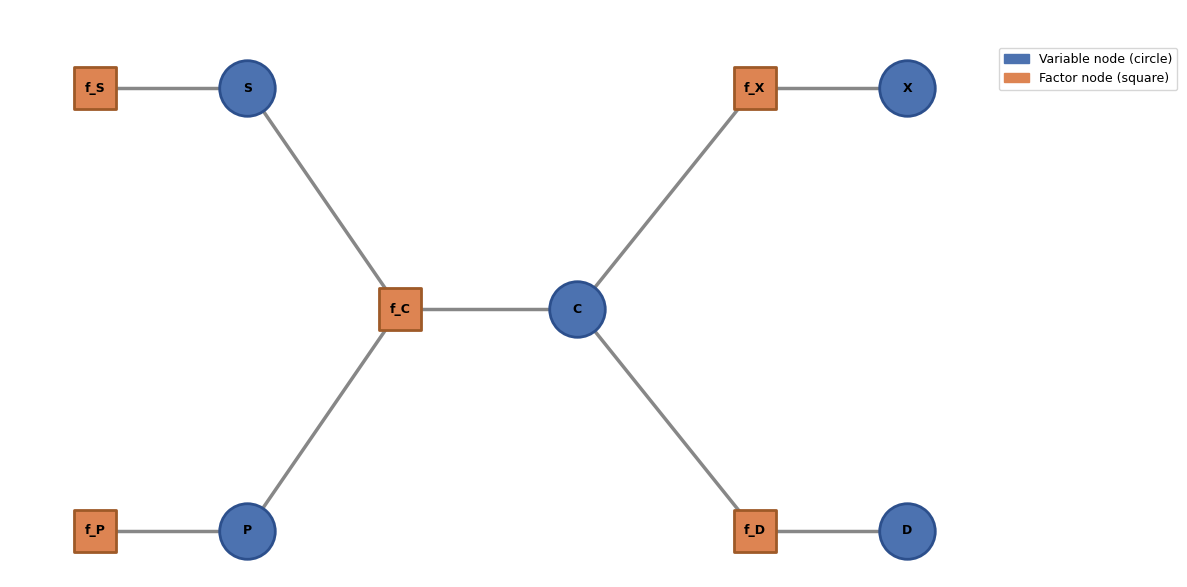

In [8]:
def draw_factor_graph(highlighted_messages=None, title="Medical Diagnosis Factor Graph",
                      node_beliefs=None, ax=None):
    """
    Draw the medical diagnosis factor graph.
    
    Parameters
    ----------
    highlighted_messages : list of (u, v, label, color) tuples
        Edges to annotate with message arrows and labels.
    title : str
        Plot title.
    node_beliefs : dict {node_name: belief_array}
        If provided, display belief probabilities inside variable nodes.
    ax : matplotlib Axes
        Axes to draw on; creates new figure if None.
    """
    G = nx.Graph()

    # Node definitions
    var_nodes    = ['S', 'P', 'C', 'X', 'D']
    factor_nodes = ['f_S', 'f_P', 'f_C', 'f_X', 'f_D']

    G.add_nodes_from(var_nodes)
    G.add_nodes_from(factor_nodes)

    # Edges: variable <-> factor
    edges = [
        ('S', 'f_S'),           # Smoking prior
        ('P', 'f_P'),           # Pollution prior
        ('S', 'f_C'),           # Smoking -> Cancer factor
        ('P', 'f_C'),           # Pollution -> Cancer factor
        ('C', 'f_C'),           # Cancer <-> joint factor
        ('C', 'f_X'),           # Cancer -> X-Ray factor
        ('X', 'f_X'),           # X-Ray <-> its factor
        ('C', 'f_D'),           # Cancer -> Dyspnoea factor
        ('D', 'f_D'),           # Dyspnoea <-> its factor
    ]
    G.add_edges_from(edges)

    # Layout positions (manually placed for clarity)
    pos = {
        'f_S': (-3.2,  0.0),  'S': (-2.0,  0.0),
        'f_P': (-3.2, -2.0),  'P': (-2.0, -2.0),
        'f_C': (-0.8, -1.0),  'C': ( 0.6, -1.0),
        'f_X': ( 2.0,  0.0),  'X': ( 3.2,  0.0),
        'f_D': ( 2.0, -2.0),  'D': ( 3.2, -2.0),
    }

    create_fig = (ax is None)
    if create_fig:
        fig, ax = plt.subplots(figsize=(12, 6))

    # Draw edges
    nx.draw_networkx_edges(G, pos, ax=ax, width=2.5, edge_color='#555555', alpha=0.7)

    # Draw variable nodes (circles)
    nx.draw_networkx_nodes(G, pos, nodelist=var_nodes, ax=ax,
                           node_shape='o', node_color='#4C72B0',
                           node_size=1600, linewidths=2, edgecolors='#2c4f8c')

    # Draw factor nodes (squares — approximated with 's')
    nx.draw_networkx_nodes(G, pos, nodelist=factor_nodes, ax=ax,
                           node_shape='s', node_color='#DD8452',
                           node_size=900, linewidths=2, edgecolors='#9e5a28')

    # Node labels
    if node_beliefs:
        labels = {}
        for n in var_nodes:
            if n in node_beliefs:
                b = node_beliefs[n]
                labels[n] = f"{n}\nP=1:{b[1]:.2f}"
            else:
                labels[n] = n
        for n in factor_nodes:
            labels[n] = n
    else:
        labels = {n: n for n in G.nodes()}

    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax,
                            font_color='black', font_weight='bold', font_size=9)

    # Highlighted message arrows
    if highlighted_messages:
        for (u, v, msg_label, color) in highlighted_messages:
            x0, y0 = pos[u]; x1, y1 = pos[v]
            dx, dy = x1 - x0, y1 - y0
            ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                        arrowprops=dict(arrowstyle="-|>", color=color,
                                        lw=2.5, mutation_scale=20))
            mx, my = (x0+x1)/2 + 0.05, (y0+y1)/2 + 0.15
            ax.text(mx, my, msg_label, fontsize=8, color=color,
                    ha='center', va='bottom', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                              edgecolor=color, alpha=0.9))

    # Legend
    legend_handles = [
        mpatches.Patch(color='#4C72B0', label='Variable node (circle)'),
        mpatches.Patch(color='#DD8452', label='Factor node (square)'),
    ]
    ax.legend(handles=legend_handles, fontsize=9,
          labelcolor='black', facecolor='white', edgecolor='#cccccc', bbox_to_anchor=(1, 1))
    ax.set_title(title, fontsize=14, pad=12)
    ax.axis('off')

    if create_fig:
        plt.tight_layout()
        plt.show()

# Draw the base graph
draw_factor_graph(title="Medical Diagnosis Factor Graph — Base Structure")


### 📝 Theoretical Question 1 — Graph Structure

Answer the following questions based on your observation of the factor graph above.

**Q1a.** Identify all the **leaf nodes** (both variable and factor nodes) in the factor graph. A leaf node has degree 1 (connected to exactly one other node).

> **📝 Answer:** *(Write your answer here)*

---

**Q1b.** The graph above is a **tree** (no cycles). Why is this property important for the Sum-Product and Max-Product algorithms? What would happen if there were cycles?

> **📝 Answer:** *(Write your answer here)*

---

**Q1c.** Consider the variable $C$ (Cancer). Which variables are **directly** connected to $C$ via a shared factor? What does this neighbourhood tell us about the conditional independence properties of the model? (Hint: think about the Markov blanket of $C$.)

> **📝 Answer:** *(Write your answer here)*


---
## Part 2 — The Sum-Product Algorithm

### 2.1  Algorithm Overview

The **Sum-Product Algorithm** (also called **Belief Propagation**) computes **exact marginal probabilities** $p(x_i)$ for every variable $x_i$ in a tree-structured factor graph.

The algorithm works by **passing messages** along the edges of the factor graph. There are two types of messages:

---

#### Message from a Variable node $x$ to a Factor node $f$:

$$\mu_{x \to f}(x) = \prod_{g \in \text{ne}(x) \setminus f} \mu_{g \to x}(x)$$

*A variable collects all incoming messages from its neighbouring factors (except the recipient factor $f$) and multiplies them together.*

---

#### Message from a Factor node $f$ to a Variable node $x$:

$$\mu_{f \to x}(x) = \sum_{\sim\{x\}} \left[ f(\mathbf{x}_{\partial f}) \prod_{y \in \text{ne}(f) \setminus x} \mu_{y \to f}(y) \right]$$

*A factor sums out all variables except $x$, weighting by the factor table and all incoming variable messages (except from $x$).*

---

#### Belief (marginal) at a Variable node $x$:

$$b(x) \propto \prod_{f \in \text{ne}(x)} \mu_{f \to x}(x)$$

*The belief is the **product of all incoming messages** from every neighbouring factor, then normalised.*

---

### 2.2  Message Passing Schedule

For a **tree graph**, we process messages from **leaves to root** (upward pass), then from **root to leaves** (downward pass).

In our graph, the natural root is $C$ (Cancer), as it is the most clinically interesting variable and sits at the centre of the graph.

**Upward pass** (leaves $\to$ $C$):

| Step | Message | Direction |
|------|---------|-----------|
| 1 | $\mu_{f_S \to S}$ | Leaf factor $f_S$ → variable $S$ |
| 2 | $\mu_{S \to f_C}$ | Variable $S$ → factor $f_C$ |
| 3 | $\mu_{f_P \to P}$ | Leaf factor $f_P$ → variable $P$ |
| 4 | $\mu_{P \to f_C}$ | Variable $P$ → factor $f_C$ |
| 5 | $\mu_{X \to f_X}$ | Leaf variable $X$ → factor $f_X$ |
| 6 | $\mu_{f_X \to C}$ | Factor $f_X$ → variable $C$ |
| 7 | $\mu_{D \to f_D}$ | Leaf variable $D$ → factor $f_D$ |
| 8 | $\mu_{f_D \to C}$ | Factor $f_D$ → variable $C$ |
| 9 | $\mu_{f_C \to C}$ | Central factor $f_C$ → root $C$ |

**Downward pass** ($C$ $\to$ leaves): required to compute marginals of $S$, $P$, $X$, $D$.


### 2.3  Implementing the Upward Pass

We now implement the message passing step by step. Each message is a **vector** over the domain of the target variable (here, always 2 values: 0 and 1).

Study the provided messages carefully, then implement the missing ones.


In [11]:
# ============================================================
#  SUM-PRODUCT: UPWARD PASS  (Leaves → Root C)
# ============================================================

print("=" * 60)
print("  UPWARD PASS: Computing messages from leaves toward C")
print("=" * 60)

# ----------------------------------------------------------
# STEP 1 & 2: Leaf factor f_S → S → f_C
# ----------------------------------------------------------
# f_S is a unary factor: phi_S(s) = P(S=s)
# Message from leaf factor f_S to variable S:
#   mu_{f_S -> S}(s) = phi_S(s)    [unary factor, no other variables]
mu_fS_to_S = phi_S.copy()   # shape: [2]

# Message from variable S to factor f_C:
#   mu_{S -> f_C}(s) = mu_{f_S -> S}(s)
#   (S has exactly two neighbours: f_S and f_C. Going toward f_C, we
#    multiply all incoming messages except from f_C → only mu_{f_S->S})
mu_S_to_fC = mu_fS_to_S.copy()   # shape: [2]

print(f"\n[Step 1] mu_{{f_S -> S}}   = {mu_fS_to_S}")
print(f"[Step 2] mu_{{S -> f_C}}   = {mu_S_to_fC}")

# ----------------------------------------------------------
# STEP 3 & 4: Leaf factor f_P → P → f_C
# ----------------------------------------------------------
# Similar to above for the Pollution variable.
mu_fP_to_P = phi_P.copy()   # shape: [2]
mu_P_to_fC = mu_fP_to_P.copy()   # shape: [2]

print(f"\n[Step 3] mu_{{f_P -> P}}   = {mu_fP_to_P}")
print(f"[Step 4] mu_{{P -> f_C}}   = {mu_P_to_fC}")

# ----------------------------------------------------------
# STEP 5 & 6: Leaf variable X → f_X → C
# ----------------------------------------------------------
# X is a leaf variable with NO unary factor.
# Message from leaf variable X to factor f_X:
#   mu_{X -> f_X}(x) = 1  for all x   (uniform, no prior information)
mu_X_to_fX = np.ones(2)   # shape: [2]

# Message from factor f_X to variable C:
#   mu_{f_X -> C}(c) = sum_x  phi_X(c, x) * mu_{X -> f_X}(x)
# This is a marginalisation: for each value of c, sum over all x
# weighted by the factor phi_X and the incoming message from X.
mu_fX_to_C = np.einsum('cx,x->c', phi_X, mu_X_to_fX)   # shape: [2]
# Equivalent: mu_fX_to_C[c] = sum_x phi_X[c,x] * mu_X_to_fX[x]

print(f"\n[Step 5] mu_{{X -> f_X}}   = {mu_X_to_fX}")
print(f"[Step 6] mu_{{f_X -> C}}   = {mu_fX_to_C}")

# ----------------------------------------------------------
# STEP 7 & 8: Leaf variable D → f_D → C
# ----------------------------------------------------------
# D is also a leaf variable with no unary factor.
# *** YOUR CODE HERE (Steps 7 & 8) ***

# Message from leaf variable D to factor f_D
mu_D_to_fD = np.ones(2)   # shape: [2]   ### YOUR CODE HERE ###

# Message from factor f_D to variable C:
#   mu_{f_D -> C}(c) = sum_d  phi_D(c, d) * mu_{D -> f_D}(d)
mu_fD_to_C = np.einsum('cd,d->c', phi_D, mu_D_to_fD)   ### YOUR CODE HERE ###

print(f"\n[Step 7] mu_{{D -> f_D}}   = {mu_D_to_fD}")
print(f"[Step 8] mu_{{f_D -> C}}   = {mu_fD_to_C}")

# ----------------------------------------------------------
# STEP 9: Central factor f_C → C
# ----------------------------------------------------------
# mu_{f_C -> C}(c) = sum_s sum_p  phi_C(s,p,c) * mu_{S->f_C}(s) * mu_{P->f_C}(p)
# This marginalises out S and P, incorporating their upstream messages.
mu_fC_to_C = np.einsum('spc,s,p->c', phi_C, mu_S_to_fC, mu_P_to_fC)   # shape: [2]

print(f"\n[Step 9] mu_{{f_C -> C}}   = {mu_fC_to_C}")
print()
print("✅ Upward pass complete (check your Step 7 & 8 outputs above).")


  UPWARD PASS: Computing messages from leaves toward C

[Step 1] mu_{f_S -> S}   = [0.5 0.5]
[Step 2] mu_{S -> f_C}   = [0.5 0.5]

[Step 3] mu_{f_P -> P}   = [0.9 0.1]
[Step 4] mu_{P -> f_C}   = [0.9 0.1]

[Step 5] mu_{X -> f_X}   = [1. 1.]
[Step 6] mu_{f_X -> C}   = [1. 1.]

[Step 7] mu_{D -> f_D}   = [1. 1.]
[Step 8] mu_{f_D -> C}   = [1. 1.]

[Step 9] mu_{f_C -> C}   = [0.8765 0.1235]

✅ Upward pass complete (check your Step 7 & 8 outputs above).


### 2.4  Computing the Belief at C

Once we have all incoming messages at $C$, the belief is their **product** (then normalised):

$$b(C) \propto \mu_{f_C \to C}(c) \cdot \mu_{f_X \to C}(c) \cdot \mu_{f_D \to C}(c)$$

> **Note:** $C$ has exactly three factor neighbours: $f_C$, $f_X$, $f_D$.  
> There are no unary factors on $C$ itself.


In [12]:
# ============================================================
#  COMPUTING BELIEF AT ROOT NODE C
# ============================================================

# Belief at C = product of ALL incoming factor-to-variable messages
# b(c) ∝ mu_{f_C->C}(c)  *  mu_{f_X->C}(c)  *  mu_{f_D->C}(c)

# *** YOUR CODE HERE ***
# Multiply the three incoming messages element-wise, then normalise.
# Hint: use element-wise multiplication (*) and divide by the sum.

belief_C_unnorm = mu_fC_to_C * mu_fD_to_C * mu_fX_to_C   ### YOUR CODE HERE: product of the three messages ###
belief_C = belief_C_unnorm / np.sum(belief_C_unnorm)         ### YOUR CODE HERE: normalise belief_C_unnorm ###

print("Unnormalised belief at C:", belief_C_unnorm)
print("Normalised  belief at C:", belief_C)
print()
print(f"  P(C=0) = {belief_C[0]:.4f}  (no lung cancer)")
print(f"  P(C=1) = {belief_C[1]:.4f}  (lung cancer)")

# ---- Validation against brute-force ----
bf_Z = 0.0
bf_mC = np.zeros(2)
for s, p, c, x, d in iterproduct(range(2), repeat=5):
    j = phi_S[s] * phi_P[p] * phi_C[s,p,c] * phi_X[c,x] * phi_D[c,d]
    bf_Z += j
    bf_mC[c] += j
bf_mC /= bf_Z

print()
print(f"  Brute-force P(C=1) = {bf_mC[1]:.4f}  ← Should match above")
assert belief_C is not None and np.allclose(belief_C, bf_mC, atol=1e-6), \
    "❌ Belief at C does not match brute-force. Check your messages!"
print("  ✅ Sum-Product belief at C matches brute-force exactly!")


Unnormalised belief at C: [0.8765 0.1235]
Normalised  belief at C: [0.8765 0.1235]

  P(C=0) = 0.8765  (no lung cancer)
  P(C=1) = 0.1235  (lung cancer)

  Brute-force P(C=1) = 0.1235  ← Should match above
  ✅ Sum-Product belief at C matches brute-force exactly!


### 2.5  Downward Pass — Marginals for All Variables

To compute the marginals of $S$, $P$, $X$, and $D$, we must run the **downward pass**: sending messages from $C$ back toward the leaves.

#### Downward messages from $C$

When computing the downward message from $C$ to a factor $f$, we exclude that factor's own incoming message:

$$\mu_{C \to f_X}(c) = \mu_{f_C \to C}(c) \cdot \mu_{f_D \to C}(c)$$

(All messages into $C$ **except** from $f_X$.)

Similarly:

$$\mu_{C \to f_D}(c) = \mu_{f_C \to C}(c) \cdot \mu_{f_X \to C}(c)$$

$$\mu_{C \to f_C}(c) = \mu_{f_X \to C}(c) \cdot \mu_{f_D \to C}(c)$$


In [ ]:
# ============================================================
#  SUM-PRODUCT: DOWNWARD PASS  (Root C → Leaves)
# ============================================================

print("=" * 60)
print("  DOWNWARD PASS: Computing messages from C toward leaves")
print("=" * 60)

# ----------------------------------------------------------
# Message C → f_X  (exclude f_X's own contribution to C)
# mu_{C -> f_X}(c) = mu_{f_C->C}(c) * mu_{f_D->C}(c)
# ----------------------------------------------------------
mu_C_to_fX = mu_fC_to_C * mu_fD_to_C   # shape: [2]

# Message f_X → X  (downward direction)
# mu_{f_X -> X}(x) = sum_c  phi_X(c,x) * mu_{C->f_X}(c)
mu_fX_to_X = np.einsum('cx,c->x', phi_X, mu_C_to_fX)   # shape: [2]

# Belief at X = mu_{X->f_X}(x)  *  mu_{f_X->X}(x)  [then normalise]
belief_X = mu_X_to_fX * mu_fX_to_X
belief_X = belief_X / belief_X.sum()

print(f"\n  mu_{{C -> f_X}} = {mu_C_to_fX}")
print(f"  mu_{{f_X -> X}} = {mu_fX_to_X}")
print(f"  Belief at X   : P(X=1) = {belief_X[1]:.4f}")

# ----------------------------------------------------------
# Message C → f_D  and belief at D
# *** YOUR CODE HERE ***
# ----------------------------------------------------------

# mu_{C -> f_D}(c) = mu_{f_C->C}(c) * mu_{f_X->C}(c)
mu_C_to_fD = None   ### YOUR CODE HERE ###

# mu_{f_D -> D}(d) = sum_c  phi_D(c,d) * mu_{C->f_D}(c)
mu_fD_to_D = None   ### YOUR CODE HERE ###

# Belief at D
belief_D_unnorm = None   ### YOUR CODE HERE ###
belief_D = None          ### YOUR CODE HERE: normalise ###

print(f"\n  mu_{{C -> f_D}} = {mu_C_to_fD}")
print(f"  mu_{{f_D -> D}} = {mu_fD_to_D}")
print(f"  Belief at D   : P(D=1) = {belief_D[1]:.4f}")

# ----------------------------------------------------------
# Message C → f_C → S and C → f_C → P
# mu_{C -> f_C}(c) = mu_{f_X->C}(c) * mu_{f_D->C}(c)
# ----------------------------------------------------------
mu_C_to_fC = mu_fX_to_C * mu_fD_to_C   # shape: [2]

# Message f_C → S:
# mu_{f_C -> S}(s) = sum_p sum_c  phi_C(s,p,c) * mu_{P->f_C}(p) * mu_{C->f_C}(c)
mu_fC_to_S = np.einsum('spc,p,c->s', phi_C, mu_P_to_fC, mu_C_to_fC)   # shape: [2]

# Belief at S
belief_S = mu_S_to_fC * mu_fC_to_S
belief_S = belief_S / belief_S.sum()

print(f"\n  mu_{{C -> f_C}} = {mu_C_to_fC}")
print(f"  mu_{{f_C -> S}} = {mu_fC_to_S}")
print(f"  Belief at S   : P(S=1) = {belief_S[1]:.4f}")

# Message f_C → P:
# *** YOUR CODE HERE ***
mu_fC_to_P = None   ### YOUR CODE HERE ###
belief_P = None      ### YOUR CODE HERE: mu_P_to_fC * mu_fC_to_P, normalised ###

print(f"\n  mu_{{f_C -> P}} = {mu_fC_to_P}")
print(f"  Belief at P   : P(P=1) = {belief_P[1]:.4f}")


### 2.6  Summary and Visualisation of All Marginals


In [ ]:
# ============================================================
#  VALIDATE ALL MARGINALS AND PLOT
# ============================================================

# --- Brute-force reference for all variables ---
bf_mS = np.zeros(2); bf_mP = np.zeros(2)
bf_mC = np.zeros(2); bf_mX = np.zeros(2); bf_mD = np.zeros(2)
bf_Z  = 0.0

for s, p, c, x, d in iterproduct(range(2), repeat=5):
    j = phi_S[s] * phi_P[p] * phi_C[s,p,c] * phi_X[c,x] * phi_D[c,d]
    bf_Z   += j
    bf_mS[s] += j; bf_mP[p] += j; bf_mC[c] += j
    bf_mX[x] += j; bf_mD[d] += j

bf_mS /= bf_Z; bf_mP /= bf_Z; bf_mC /= bf_Z
bf_mX /= bf_Z; bf_mD /= bf_Z

sp_beliefs = {
    'S': belief_S, 'P': belief_P, 'C': belief_C,
    'X': belief_X, 'D': belief_D
}
bf_beliefs = {
    'S': bf_mS,   'P': bf_mP,   'C': bf_mC,
    'X': bf_mX,   'D': bf_mD
}

print("=" * 55)
print(f"  {'Variable':<10} {'SP P(=1)':<14} {'BF P(=1)':<14} {'Match'}")
print("-" * 55)
all_ok = True
for var in ['S', 'P', 'C', 'X', 'D']:
    sp_val = sp_beliefs[var][1] if sp_beliefs[var] is not None else float('nan')
    bf_val = bf_beliefs[var][1]
    ok = np.isclose(sp_val, bf_val, atol=1e-5)
    all_ok = all_ok and ok
    status = "✅" if ok else "❌"
    print(f"  {var:<10} {sp_val:<14.6f} {bf_val:<14.6f} {status}")
print("=" * 55)
if all_ok:
    print("\n  🎉 All marginals match brute-force! Sum-Product is correct.")
else:
    print("\n  ⚠️  Some marginals differ — re-check your incomplete steps.")

# ---- Visualisation ----
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
var_labels = ['S\n(Smoking)', 'P\n(Pollution)', 'C\n(Cancer)',
              'X\n(X-Ray+)', 'D\n(Dyspnoea)']
vars_list  = ['S', 'P', 'C', 'X', 'D']
colors     = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

for i, (var, label, color) in enumerate(zip(vars_list, var_labels, colors)):
    ax = axes[i]
    b = sp_beliefs[var]
    if b is not None:
        ax.bar([0, 1], b, color=[color]*2, alpha=0.85, edgecolor='white', linewidth=1.5)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['0 (No)', '1 (Yes)'])
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Probability' if i == 0 else '')
        for j, v in enumerate(b):
            ax.text(j, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(label, fontsize=11)
    ax.set_facecolor('#f8f9fa')
    ax.spines[['top','right']].set_visible(False)

fig.suptitle("Marginal Probabilities — Sum-Product Algorithm (No Observations)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ---- Annotated graph showing beliefs ----
draw_factor_graph(title="Factor Graph with Computed Marginal Beliefs",
                  node_beliefs={v: sp_beliefs[v] for v in vars_list
                                if sp_beliefs[v] is not None})


### 📝 Theoretical Question 2 — Marginal Probabilities

**Q2a.** The prior probability of smoking is $P(S=1) = 0.50$. After running the Sum-Product algorithm, you should obtain the same marginal $P(S=1) = 0.50$. Is this expected? Explain why the belief at $S$ should equal its prior in the absence of any observations.

> **📝 Answer:** *(Write your answer here)*

---

**Q2b.** The marginal $P(C=1) \approx 0.1235$. Walk through the intuition: given that 50% of patients smoke, 10% are in polluted areas, and the CPT values for cancer, does this probability seem reasonable? What is the dominant factor driving cancer risk in this population?

> **📝 Answer:** *(Write your answer here)*

---

**Q2c.** Compare $P(X=1) \approx 0.143$ to the true positive rate of the X-Ray ($P(X=1|C=1) = 0.80$). Why is $P(X=1)$ much lower? What does this tell us about the **base rate effect** in medical testing?

> **📝 Answer:** *(Write your answer here)*


---
## Part 3 — Inference with Evidence (Observations)

### 3.1  Incorporating Observations

One of the most powerful uses of belief propagation is **updating beliefs when we observe evidence**.

When a variable $x_i$ is **observed** to take value $\hat{x}$, we simply set its outgoing message to a delta function:

$$\mu_{x_i \to f}(x) = \begin{cases} 1 & \text{if } x = \hat{x} \\ 0 & \text{otherwise} \end{cases}$$

This effectively clamps the variable and propagates the information through the graph, updating all other beliefs via Bayes' theorem — **automatically** through message passing.

### 3.2  Scenario: Positive X-Ray Result

Imagine the physician observes that the patient's **chest X-Ray is positive** ($X = 1$).

**Clinical question:** *How much does a positive X-Ray increase the probability of lung cancer?*

We re-run the Sum-Product algorithm with this observation.


In [ ]:
# ============================================================
#  SUM-PRODUCT WITH EVIDENCE: X = 1  (Positive X-Ray)
# ============================================================

# --- Hard evidence: observe X = 1 ---
# mu_{X -> f_X}(x) = [0, 1]  (X is clamped to 1)
obs_X = 1
mu_X_to_fX_evidence = np.zeros(2)
mu_X_to_fX_evidence[obs_X] = 1.0   # Delta at observed value

print(f"Observed: X = {obs_X}  (Positive X-Ray)")
print(f"Evidence message mu_{{X->f_X}} = {mu_X_to_fX_evidence}")
print()

# --- Re-run upward pass (only f_X message changes) ---
# All other upward messages are the same as before
mu_fX_to_C_ev = np.einsum('cx,x->c', phi_X, mu_X_to_fX_evidence)   # Now uses evidence

print(f"mu_{{f_X -> C}} (with evidence) = {mu_fX_to_C_ev}")
print(f"  Compare to no-evidence:      = {mu_fX_to_C}")

# *** YOUR CODE HERE ***
# Recompute belief at C using the new mu_{f_X->C}_ev.
# The other messages (mu_fC_to_C, mu_fD_to_C) remain unchanged.

belief_C_given_X1 = None   ### YOUR CODE HERE: product + normalise ###

print()
print(f"  P(C=1 | X=1)  via SP  = {belief_C_given_X1[1]:.4f}")

# Brute-force check
bf_Z_ev = 0.0; bf_mC_ev = np.zeros(2)
for s, p, c, d in iterproduct(range(2), repeat=4):
    j = phi_S[s] * phi_P[p] * phi_C[s,p,c] * phi_X[c, obs_X] * phi_D[c,d]
    bf_Z_ev   += j
    bf_mC_ev[c] += j
bf_mC_ev /= bf_Z_ev
print(f"  P(C=1 | X=1)  brute-force = {bf_mC_ev[1]:.4f}  ← Should match")


### 3.3  Scenario: Dyspnoea Observed — Joint Evidence

Now consider the patient also presents with **dyspnoea** ($D = 1$, shortness of breath).

**Clinical question:** *How does the combination of a positive X-Ray AND dyspnoea affect the cancer probability?*


In [ ]:
# ============================================================
#  SUM-PRODUCT WITH JOINT EVIDENCE: X=1, D=1
# ============================================================

obs_X2, obs_D2 = 1, 1   # X=1 (positive X-Ray), D=1 (dyspnoea present)

# Evidence messages
mu_X_to_fX_ev2 = np.zeros(2); mu_X_to_fX_ev2[obs_X2] = 1.0
mu_D_to_fD_ev2 = np.zeros(2); mu_D_to_fD_ev2[obs_D2] = 1.0

# Messages from factors to C
mu_fX_to_C_ev2 = np.einsum('cx,x->c', phi_X, mu_X_to_fX_ev2)
mu_fD_to_C_ev2 = np.einsum('cd,d->c', phi_D, mu_D_to_fD_ev2)

# Belief at C under joint evidence
# *** YOUR CODE HERE ***
belief_C_given_X1D1 = None   ### YOUR CODE HERE ###

print(f"  P(C=1 | X=1, D=1) via SP       = {belief_C_given_X1D1[1]:.4f}")

# Brute-force check
bf_Z3 = 0.0; bf_mC3 = np.zeros(2)
for s, p, c in iterproduct(range(2), repeat=3):
    j = phi_S[s] * phi_P[p] * phi_C[s,p,c] * phi_X[c, obs_X2] * phi_D[c, obs_D2]
    bf_Z3 += j; bf_mC3[c] += j
bf_mC3 /= bf_Z3
print(f"  P(C=1 | X=1, D=1) brute-force  = {bf_mC3[1]:.4f}  ← Should match")

# ---- Comparison Plot ----
scenarios = ['Prior\n(no obs.)', 'X=1\n(Positive X-Ray)', 'X=1, D=1\n(X-Ray + Dyspnoea)']
p_cancer  = [
    bf_mC[1],
    bf_mC_ev[1],
    bf_mC3[1],
]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(scenarios, p_cancer, color=['#4C72B0','#DD8452','#C44E52'],
              width=0.5, edgecolor='white', linewidth=2)
ax.set_ylim(0, 1.0)
ax.set_ylabel('P(Cancer = 1)', fontsize=12)
ax.set_title('Posterior Probability of Cancer Under Different Evidence', fontsize=13)
for bar, val in zip(bars, p_cancer):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

# Reference lines
ax.axhline(0.5, color='gray', linestyle='--', lw=1, alpha=0.5, label='50% threshold')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


### 3.4  Visualising Message Updates with Evidence

The figure below shows which messages **change** when we introduce evidence at $X$, highlighting the information flow.


In [ ]:
# ============================================================
#  VISUALISE MESSAGE FLOW UNDER EVIDENCE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# LEFT: Base graph — upward messages (no evidence)
msgs_up = [
    ('f_S', 'S',   'μ(f_S→S)',  '#27ae60'),
    ('S',   'f_C', 'μ(S→f_C)', '#27ae60'),
    ('f_P', 'P',   'μ(f_P→P)',  '#27ae60'),
    ('P',   'f_C', 'μ(P→f_C)', '#27ae60'),
    ('X',   'f_X', 'μ(X→f_X)', '#27ae60'),
    ('f_X', 'C',   'μ(f_X→C)', '#27ae60'),
    ('D',   'f_D', 'μ(D→f_D)', '#27ae60'),
    ('f_D', 'C',   'μ(f_D→C)', '#27ae60'),
    ('f_C', 'C',   'μ(f_C→C)', '#27ae60'),
]
draw_factor_graph(highlighted_messages=msgs_up,
                  title="Upward Pass — All Messages (No Evidence)", ax=axes[0])

# RIGHT: Evidence X=1 — only changed message highlighted in red
msgs_ev = [
    ('X',   'f_X', 'μ(X→f_X)\n=[0,1]', '#e74c3c'),   # Changed (evidence)
    ('f_X', 'C',   'μ(f_X→C)\nupdated', '#e74c3c'),   # Changed
    ('f_C', 'C',   'μ(f_C→C)',            '#7f8c8d'),   # Unchanged
    ('f_D', 'C',   'μ(f_D→C)',            '#7f8c8d'),   # Unchanged
]
draw_factor_graph(highlighted_messages=msgs_ev,
                  title="Evidence X=1 — Red = Changed Messages, Grey = Unchanged",
                  ax=axes[1])

plt.tight_layout()
plt.show()


### 📝 Theoretical Question 3 — Evidence and Belief Updating

**Q3a.** Before seeing any test results, $P(C=1) \approx 0.124$. After observing a positive X-Ray ($X=1$), the posterior $P(C=1 \mid X=1)$ should jump significantly. Explain this increase using **Bayes' theorem** intuitively: what information does the X-Ray result provide, and why does it update the cancer belief so dramatically?

> **📝 Answer:** *(Write your answer here)*

---

**Q3b.** Now with both $X=1$ and $D=1$, the probability of cancer increases further. However, dyspnoea has a relatively high base rate even without cancer ($P(D=1|C=0) = 0.35$). Does observing dyspnoea provide as strong an update as the X-Ray alone? Why or why not? Think about the **likelihood ratio** for each test.

> **📝 Answer:** *(Write your answer here)*

---

**Q3c.** In the Sum-Product algorithm, when we clamp $X=1$, only the message $\mu_{X \to f_X}$ changes from $[1, 1]$ to $[0, 1]$. All other **upstream** messages (from $S$, $P$, $f_C$) remain identical. Explain why this is the case and what this tells us about the **modularity** of belief propagation.

> **📝 Answer:** *(Write your answer here)*


---
## Part 4 — The Max-Product Algorithm with Backtracking

### 4.1  From Marginals to MAP

The Sum-Product algorithm computes **marginal** distributions: $p(x_i)$ for each variable independently.

Sometimes, we want the **most probable explanation (MPE)** — a single joint assignment $\mathbf{x}^* = (x_1^*, \ldots, x_n^*)$ that maximises the joint probability:

$$\mathbf{x}^* = \underset{\mathbf{x}}{\arg\max} \; p(\mathbf{x})$$

This is the **MAP (Maximum A Posteriori)** inference problem. Naively, it requires searching over $2^n$ configurations — exponential in the number of variables.

The **Max-Product Algorithm** solves this efficiently on tree graphs using the same message-passing structure as Sum-Product, but replacing **summation** with **maximisation**:

$$\mu_{f \to x}(x) = \max_{\sim\{x\}} \left[ f(\mathbf{x}_{\partial f}) \prod_{y \in \text{ne}(f) \setminus x} \mu_{y \to f}(y) \right]$$

### 4.2  Log-Domain for Numerical Stability

Products of many small probabilities quickly underflow to zero. We work in **log space**:

$$\log \mu_{f \to x}(x) = \max_{\sim\{x\}} \left[ \log f(\mathbf{x}_{\partial f}) + \sum_{y \in \text{ne}(f) \setminus x} \log \mu_{y \to f}(y) \right]$$

### 4.3  Backtracking

The max-product algorithm computes the **value** of the MAP solution, but to recover the actual assignment we need **backtracking**: at each max-operation, we store the argmax index so we can trace back the optimal configuration from root to leaves.


In [ ]:
# ============================================================
#  MAX-PRODUCT ALGORITHM (Log Domain) — UPWARD PASS
# ============================================================

print("=" * 60)
print("  MAX-PRODUCT: Computing max-messages (log domain)")
print("=" * 60)

# Work in log-domain to prevent underflow
LOG_EPS = 1e-300   # prevent log(0)

log_phi_S = np.log(phi_S + LOG_EPS)
log_phi_P = np.log(phi_P + LOG_EPS)
log_phi_C = np.log(phi_C + LOG_EPS)   # shape: [S, P, C]
log_phi_X = np.log(phi_X + LOG_EPS)   # shape: [C, X]
log_phi_D = np.log(phi_D + LOG_EPS)   # shape: [C, D]

# ----------------------------------------------------------
# Leaf messages (identical structure to Sum-Product, but log)
# ----------------------------------------------------------
log_mu_fS_to_S = log_phi_S.copy()     # = log phi_S(s)
log_mu_S_to_fC = log_mu_fS_to_S.copy()

log_mu_fP_to_P = log_phi_P.copy()
log_mu_P_to_fC = log_mu_fP_to_P.copy()

# Leaf X (no prior)
log_mu_X_to_fX = np.zeros(2)   # log(1) = 0

# Max-message: f_X → C  (MAX over x, not sum)
# log_mu_{f_X->C}(c) = max_x [ log phi_X(c,x) + log mu_{X->f_X}(x) ]
log_mu_fX_to_C = np.max(log_phi_X + log_mu_X_to_fX[np.newaxis, :], axis=1)
argmax_X_given_C = np.argmax(log_phi_X + log_mu_X_to_fX[np.newaxis, :], axis=1)

print(f"\n  log_mu_{{f_X->C}} = {log_mu_fX_to_C}")
print(f"  argmax_X_given_C = {argmax_X_given_C}  (optimal X for each value of C)")

# Leaf D (no prior)
log_mu_D_to_fD = np.zeros(2)

# *** YOUR CODE HERE ***
# Max-message: f_D → C
# log_mu_{f_D->C}(c) = max_d [ log phi_D(c,d) + log mu_{D->f_D}(d) ]
log_mu_fD_to_C   = None   ### YOUR CODE HERE ###
argmax_D_given_C = None   ### YOUR CODE HERE: np.argmax over d axis ###

print(f"\n  log_mu_{{f_D->C}} = {log_mu_fD_to_C}")
print(f"  argmax_D_given_C = {argmax_D_given_C}")

# ----------------------------------------------------------
# Max-message: f_C → C
# log_mu_{f_C->C}(c) = max_s max_p [log phi_C(s,p,c) + log mu_{S->fC}(s) + log mu_{P->fC}(p)]
# ----------------------------------------------------------
# Build joint log-score array over (s, p, c)
log_joint_spc = (log_phi_C                          # [S, P, C]
                 + log_mu_S_to_fC[:, None, None]    # broadcast over P, C
                 + log_mu_P_to_fC[None, :, None])   # broadcast over S, C

# Flatten (s,p) into one axis → shape [S*P, C] = [4, 2]
log_joint_flat = log_joint_spc.reshape(4, 2)

log_mu_fC_to_C    = np.max(log_joint_flat, axis=0)    # shape: [2]
argmax_SP_given_C = np.argmax(log_joint_flat, axis=0)  # shape: [2], encodes s*2+p

print(f"\n  log_mu_{{f_C->C}} = {log_mu_fC_to_C}")
print(f"  argmax_(S,P) given C : indices = {argmax_SP_given_C}")
print(f"    C=0 → S={argmax_SP_given_C[0]//2}, P={argmax_SP_given_C[0]%2}")
print(f"    C=1 → S={argmax_SP_given_C[1]//2}, P={argmax_SP_given_C[1]%2}")


In [ ]:
# ============================================================
#  MAX-PRODUCT: MAP ASSIGNMENT VIA BACKTRACKING
# ============================================================

print("=" * 60)
print("  BACKTRACKING: Recovering optimal assignment")
print("=" * 60)

# *** YOUR CODE HERE ***
# Step 1: Compute log-belief at C (sum of all incoming log-messages)
# log_belief_C(c) = log_mu_fC_to_C(c) + log_mu_fX_to_C(c) + log_mu_fD_to_C(c)
log_belief_C = None   ### YOUR CODE HERE ###

# Step 2: Find MAP value of C
c_map = None          ### YOUR CODE HERE: np.argmax(log_belief_C) ###

print(f"\n  log-belief at C = {log_belief_C}")
print(f"  MAP C* = {c_map}  ({'Cancer' if c_map==1 else 'No Cancer'})")

# ----------------------------------------------------------
# Step 3: Backtrack to find optimal S, P (from argmax_SP_given_C)
# ----------------------------------------------------------
sp_idx = argmax_SP_given_C[c_map]
s_map  = sp_idx // 2
p_map  = sp_idx %  2

# ----------------------------------------------------------
# Step 4: Backtrack to find optimal X, D (from argmax tables)
# ----------------------------------------------------------
x_map = argmax_X_given_C[c_map]
d_map = argmax_D_given_C[c_map]

print()
print("  ┌─────────────────────────────────────────┐")
print("  │       MAP Assignment (Max-Product)      │")
print("  ├────────────┬────────────────────────────┤")
print(f"  │  Smoking S │ {s_map}  ({'Smoker' if s_map else 'Non-smoker':<22}) │")
print(f"  │  Pollution P│ {p_map}  ({'High pollution' if p_map else 'Low pollution':<22}) │")
print(f"  │  Cancer  C  │ {c_map}  ({'Cancer present' if c_map else 'No cancer':<22}) │")
print(f"  │  X-Ray   X  │ {x_map}  ({'Positive' if x_map else 'Negative':<22}) │")
print(f"  │  Dyspnoea D │ {d_map}  ({'Present' if d_map else 'Absent':<22}) │")
print("  └─────────────┴────────────────────────────┘")

# --- Brute-force MAP validation ---
best_prob = -1.0
best_cfg  = None
for s, p, c, x, d in iterproduct(range(2), repeat=5):
    j = phi_S[s] * phi_P[p] * phi_C[s,p,c] * phi_X[c,x] * phi_D[c,d]
    if j > best_prob:
        best_prob = j
        best_cfg  = (s, p, c, x, d)

s_bf, p_bf, c_bf, x_bf, d_bf = best_cfg
print()
print(f"  Brute-force MAP: S={s_bf}, P={p_bf}, C={c_bf}, X={x_bf}, D={d_bf}")
print(f"  MAP joint probability = {best_prob:.8f}")

mp_prob = (phi_S[s_map] * phi_P[p_map] * phi_C[s_map,p_map,c_map]
           * phi_X[c_map,x_map] * phi_D[c_map,d_map])
print(f"  Max-product probability = {mp_prob:.8f}")

match = np.isclose(mp_prob, best_prob, atol=1e-10)
print()
print(f"  {'✅ MAP assignment matches brute-force!' if match else '❌ Mismatch — check your code.'}")


### 4.4  MAP Inference with Evidence

Now let's find the MAP assignment **given evidence**: the patient has a positive X-Ray ($X=1$) and presents with dyspnoea ($D=1$).

**Clinical question:** *Given these symptoms, what is the most likely complete explanation?*


In [ ]:
# ============================================================
#  MAX-PRODUCT WITH EVIDENCE: X=1, D=1
# ============================================================

print("MAP inference given X=1 (positive X-Ray) and D=1 (dyspnoea)")
print("=" * 60)

# Evidence messages (log domain)
log_mu_X_to_fX_ev = np.array([-np.inf, 0.0])   # X=1 clamped: log[0,1]
log_mu_D_to_fD_ev = np.array([-np.inf, 0.0])   # D=1 clamped: log[0,1]

# Updated max-messages from evidence
log_mu_fX_to_C_ev = np.max(log_phi_X + log_mu_X_to_fX_ev[np.newaxis, :], axis=1)
argmax_X_given_C_ev = np.argmax(log_phi_X + log_mu_X_to_fX_ev[np.newaxis, :], axis=1)

# *** YOUR CODE HERE ***
# Compute log_mu_fD_to_C_ev and argmax_D_given_C_ev with D=1 evidence
log_mu_fD_to_C_ev   = None   ### YOUR CODE HERE ###
argmax_D_given_C_ev = None   ### YOUR CODE HERE ###

# log_belief_C under evidence (f_C message unchanged)
log_belief_C_ev = log_mu_fC_to_C + log_mu_fX_to_C_ev + log_mu_fD_to_C_ev

c_map_ev  = np.argmax(log_belief_C_ev)
sp_idx_ev = argmax_SP_given_C[c_map_ev]
s_map_ev  = sp_idx_ev // 2
p_map_ev  = sp_idx_ev %  2
x_map_ev  = argmax_X_given_C_ev[c_map_ev]
d_map_ev  = argmax_D_given_C_ev[c_map_ev]

print()
print("  ┌─────────────────────────────────────────────┐")
print("  │  MAP Assignment given X=1, D=1 (Evidence)  │")
print("  ├────────────┬────────────────────────────────┤")
print(f"  │  Smoking S │ {s_map_ev}  ({'Smoker' if s_map_ev else 'Non-smoker':<24}) │")
print(f"  │  Pollution P│ {p_map_ev}  ({'High pollution' if p_map_ev else 'Low pollution':<24}) │")
print(f"  │  Cancer  C  │ {c_map_ev}  ({'Cancer present ← KEY' if c_map_ev else 'No cancer':<24}) │")
print(f"  │  X-Ray   X  │ {x_map_ev}  ({'Positive (observed)' if x_map_ev else 'Negative':<24}) │")
print(f"  │  Dyspnoea D │ {d_map_ev}  ({'Present (observed)' if d_map_ev else 'Absent':<24}) │")
print("  └─────────────┴────────────────────────────────┘")

# Brute-force MAP with evidence
best_prob_ev = -1.0; best_cfg_ev = None
for s, p, c in iterproduct(range(2), repeat=3):
    j = phi_S[s] * phi_P[p] * phi_C[s,p,c] * phi_X[c, 1] * phi_D[c, 1]
    if j > best_prob_ev:
        best_prob_ev = j; best_cfg_ev = (s, p, c, 1, 1)

print()
print(f"  Brute-force MAP (X=1,D=1): {best_cfg_ev}")
print(f"  C* = {best_cfg_ev[2]}  ({'Cancer' if best_cfg_ev[2]==1 else 'No Cancer'})")
mp_prob_ev = (phi_S[s_map_ev]*phi_P[p_map_ev]*phi_C[s_map_ev,p_map_ev,c_map_ev]
              *phi_X[c_map_ev,x_map_ev]*phi_D[c_map_ev,d_map_ev])
match_ev = np.isclose(mp_prob_ev, best_prob_ev, atol=1e-12)
print(f"  {'✅ Matches brute-force!' if match_ev else '❌ Mismatch — re-check.'}")


In [ ]:
# ============================================================
#  VISUALISE MAP ASSIGNMENTS ON THE FACTOR GRAPH
# ============================================================

def draw_map_assignment(assignment, evidence=None,
                        title="MAP Assignment on Factor Graph"):
    """
    Draw the factor graph with MAP-assigned variable values annotated.
    
    Parameters
    ----------
    assignment : dict {var_name: int}
        MAP assignment for each variable.
    evidence : dict {var_name: int} or None
        Observed variables (highlighted in red).
    title : str
    """
    G = nx.Graph()
    var_nodes    = ['S', 'P', 'C', 'X', 'D']
    factor_nodes = ['f_S', 'f_P', 'f_C', 'f_X', 'f_D']
    G.add_nodes_from(var_nodes + factor_nodes)
    edges = [('S','f_S'),('P','f_P'),('S','f_C'),('P','f_C'),
             ('C','f_C'),('C','f_X'),('X','f_X'),('C','f_D'),('D','f_D')]
    G.add_edges_from(edges)
    pos = {
        'f_S':(-3.2, 0.0),'S':(-2.0, 0.0),
        'f_P':(-3.2,-2.0),'P':(-2.0,-2.0),
        'f_C':(-0.8,-1.0),'C':( 0.6,-1.0),
        'f_X':( 2.0, 0.0),'X':( 3.2, 0.0),
        'f_D':( 2.0,-2.0),'D':( 3.2,-2.0),
    }

    var_labels_map = {
        'S': 'S', 'P': 'P', 'C': 'C', 'X': 'X', 'D': 'D'
    }
    val_names = {'S': ['No smoke','Smoke'], 'P': ['Low poll','High poll'],
                 'C': ['No cancer','Cancer'], 'X': ['X-Ray−','X-Ray+'],
                 'D': ['No dysp','Dyspnoea']}

    evidence = evidence or {}
    node_colors_var = []
    labels = {}
    for n in var_nodes:
        v = assignment.get(n, '?')
        vname = val_names[n][v] if isinstance(v, int) else '?'
        labels[n] = f"{n}={v}\n{vname}"
        if n in evidence:
            node_colors_var.append('#e74c3c')   # red = observed
        else:
            node_colors_var.append('#27ae60')   # green = inferred

    for n in factor_nodes:
        labels[n] = n

    fig, ax = plt.subplots(figsize=(13, 6))
    nx.draw_networkx_edges(G, pos, ax=ax, width=2.5, edge_color='#555555', alpha=0.7)
    nx.draw_networkx_nodes(G, pos, nodelist=var_nodes, ax=ax,
                           node_shape='o', node_color=node_colors_var,
                           node_size=1800, linewidths=2, edgecolors='#1a1a1a')
    nx.draw_networkx_nodes(G, pos, nodelist=factor_nodes, ax=ax,
                           node_shape='s', node_color='#DD8452',
                           node_size=900, linewidths=2, edgecolors='#9e5a28')
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax,
                            font_color='white', font_weight='bold', font_size=8)

    legend_handles = [
        mpatches.Patch(color='#27ae60', label='Variable — inferred (MAP)'),
        mpatches.Patch(color='#e74c3c', label='Variable — observed (evidence)'),
        mpatches.Patch(color='#DD8452', label='Factor node'),
    ]
    ax.legend(handles=legend_handles, loc='lower left', fontsize=9)
    ax.set_title(title, fontsize=13, pad=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Draw MAP with no evidence
map_no_ev = {'S': s_map, 'P': p_map, 'C': c_map, 'X': x_map, 'D': d_map}
draw_map_assignment(map_no_ev, evidence={},
                    title="MAP Assignment — No Evidence")

# Draw MAP with evidence X=1, D=1
map_with_ev = {'S': s_map_ev, 'P': p_map_ev, 'C': c_map_ev,
               'X': x_map_ev, 'D': d_map_ev}
draw_map_assignment(map_with_ev, evidence={'X': 1, 'D': 1},
                    title="MAP Assignment — Evidence: X=1 (X-Ray+), D=1 (Dyspnoea)")


### 4.5  Comparing Sum-Product and Max-Product Results


In [ ]:
# ============================================================
#  COMPARISON: SUM-PRODUCT vs MAX-PRODUCT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ---- LEFT: Marginal beliefs from Sum-Product ----
ax = axes[0]
vars_list = ['S', 'P', 'C', 'X', 'D']
sp_p1 = [belief_S[1], belief_P[1], belief_C[1], belief_X[1], belief_D[1]]
colors_sp = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']
ax.bar(vars_list, sp_p1, color=colors_sp, alpha=0.85, edgecolor='white', linewidth=1.5)
for i, v in enumerate(sp_p1):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('P(variable = 1)', fontsize=11)
ax.set_title('Sum-Product: Marginal P(=1) for each variable', fontsize=12)
ax.spines[['top','right']].set_visible(False)

# ---- RIGHT: MAP assignment from Max-Product ----
ax = axes[1]
map_vals = [s_map, p_map, c_map, x_map, d_map]
bar_colors = ['#27ae60' if v == 1 else '#4C72B0' for v in map_vals]
ax.bar(vars_list, map_vals, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.5)
for i, v in enumerate(map_vals):
    ax.text(i, v + 0.02, str(v), ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.4)
ax.set_yticks([0, 1])
ax.set_yticklabels(['0 (No/Absent)', '1 (Yes/Present)'])
ax.set_ylabel('MAP value', fontsize=11)
ax.set_title('Max-Product: MAP Assignment (most probable config.)', fontsize=12)
ax.spines[['top','right']].set_visible(False)

legend_handles = [
    mpatches.Patch(color='#27ae60', label='MAP value = 1'),
    mpatches.Patch(color='#4C72B0', label='MAP value = 0'),
]
axes[1].legend(handles=legend_handles, fontsize=9)

plt.suptitle('Sum-Product vs Max-Product — No Evidence', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Key differences:")
print(f"  Sum-Product P(C=1)  = {belief_C[1]:.4f}  (marginal)")
print(f"  Max-Product C* = {c_map}           (MAP)")
print()
print("The MAP assignment is the ALL-ZEROS configuration (S=0, P=0, C=0, X=0, D=0)")
print("because priors heavily favour absence of disease.")
print("However the MARGINAL P(C=1) ≈ 12% reflects the aggregated uncertainty.")


### 📝 Theoretical Question 4 — Max-Product and MAP Inference

**Q4a.** The MAP assignment is $(S=0, P=0, C=0, X=0, D=0)$ — "everything absent". Yet the marginal $P(C=1) \approx 12\%$ is not negligible. Explain why the MAP assignment can differ from the individually most probable value of each variable (i.e., why $\arg\max_C p(C)$ can differ from the $C^*$ in the MAP assignment).

> **📝 Answer:** *(Write your answer here)*

---

**Q4b.** After observing $X=1$ and $D=1$ (positive X-Ray and dyspnoea), does the MAP assignment change for the cancer variable $C$? Compare this with the posterior marginal $P(C=1 \mid X=1, D=1)$ computed in Part 3. What does this comparison tell us?

> **📝 Answer:** *(Write your answer here)*

---

**Q4c.** The Max-Product algorithm requires **backtracking** to recover the optimal assignment. Why is it not sufficient to just take $\arg\max$ of the final beliefs at each variable independently? Give an example (even hypothetical) where such a "greedy marginal decoding" would yield a **different** (and worse) assignment than true MAP.

> **📝 Answer:** *(Write your answer here)*

---

**Q4d.** We operated in **log-domain** during Max-Product to prevent numerical underflow. Explain why the product of many small probabilities (like $0.5 \times 0.9 \times 0.97 \times 0.95 \times 0.65$) causes problems in floating-point arithmetic, and how the log-sum-max reformulation resolves this.

> **📝 Answer:** *(Write your answer here)*


---
## Part 5 — Summary Visualisation and Final Reflection

### 5.1  Complete Message-Passing Visualisation

The cell below produces a comprehensive figure showing all messages computed in the Sum-Product upward and downward passes, annotated on the factor graph.


In [ ]:
# ============================================================
#  COMPREHENSIVE MESSAGE-PASSING SUMMARY FIGURE
# ============================================================

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

ax_up   = fig.add_subplot(gs[0, 0])
ax_down = fig.add_subplot(gs[0, 1])
ax_bar  = fig.add_subplot(gs[1, 0])
ax_map  = fig.add_subplot(gs[1, 1])

# ── TOP LEFT: Upward pass messages ──────────────────────────
msgs_up_all = [
    ('f_S', 'S',   f'μ={np.round(mu_fS_to_S,2)}',    '#2980b9'),
    ('S',   'f_C', f'μ={np.round(mu_S_to_fC,2)}',    '#2980b9'),
    ('f_P', 'P',   f'μ={np.round(mu_fP_to_P,2)}',    '#8e44ad'),
    ('P',   'f_C', f'μ={np.round(mu_P_to_fC,2)}',    '#8e44ad'),
    ('X',   'f_X', f'μ={np.round(mu_X_to_fX,2)}',    '#27ae60'),
    ('f_X', 'C',   f'μ={np.round(mu_fX_to_C,3)}',    '#27ae60'),
    ('D',   'f_D', f'μ={np.round(mu_D_to_fD,2)}',    '#e67e22'),
    ('f_D', 'C',   f'μ={np.round(mu_fD_to_C,3)}',    '#e67e22'),
    ('f_C', 'C',   f'μ={np.round(mu_fC_to_C,3)}',    '#c0392b'),
]
draw_factor_graph(highlighted_messages=msgs_up_all,
                  title="Upward Pass — All Messages (Leaves → C)",
                  ax=ax_up)

# ── TOP RIGHT: Downward pass messages ───────────────────────
msgs_down_all = [
    ('C', 'f_X',  f'μ={np.round(mu_C_to_fX,3)}',   '#27ae60'),
    ('f_X', 'X',  f'μ={np.round(mu_fX_to_X,3)}',   '#27ae60'),
    ('C', 'f_D',  f'μ={np.round(mu_C_to_fD,3)}',   '#e67e22'),
    ('f_D', 'D',  f'μ={np.round(mu_fD_to_D,3)}',   '#e67e22'),
    ('C', 'f_C',  f'μ={np.round(mu_C_to_fC,3)}',   '#c0392b'),
    ('f_C', 'S',  f'μ={np.round(mu_fC_to_S,3)}',   '#2980b9'),
    ('f_C', 'P',  f'μ={np.round(mu_fC_to_P,3)}',   '#8e44ad'),
]
draw_factor_graph(highlighted_messages=msgs_down_all,
                  title="Downward Pass — All Messages (C → Leaves)",
                  ax=ax_down)

# ── BOTTOM LEFT: Marginal beliefs bar chart ──────────────────
vars_list2 = ['S', 'P', 'C', 'X', 'D']
beliefs_all = [belief_S, belief_P, belief_C, belief_X, belief_D]
bar_labels  = ['S\n(Smoking)', 'P\n(Pollution)', 'C\n(Cancer)', 'X\n(X-Ray+)', 'D\n(Dyspnoea)']
bar_colors2 = ['#2980b9','#8e44ad','#c0392b','#27ae60','#e67e22']
x_pos = np.arange(5)
p1_vals = [b[1] for b in beliefs_all]
ax_bar.bar(x_pos, p1_vals, color=bar_colors2, alpha=0.85, edgecolor='white', lw=1.5)
for i, v in enumerate(p1_vals):
    ax_bar.text(i, v + 0.015, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax_bar.set_xticks(x_pos); ax_bar.set_xticklabels(bar_labels, fontsize=10)
ax_bar.set_ylim(0, 1.05); ax_bar.set_ylabel('P(variable = 1)')
ax_bar.set_title('Sum-Product Marginals — No Evidence', fontsize=11)
ax_bar.spines[['top','right']].set_visible(False)

# ── BOTTOM RIGHT: Evidence comparison ───────────────────────
scenarios2 = ['Prior', 'X=1', 'X=1,D=1']
p_c_vals   = [bf_mC[1], bf_mC_ev[1], bf_mC3[1]]
ax_map.bar(scenarios2, p_c_vals, color=['#4C72B0','#DD8452','#C44E52'],
           width=0.45, edgecolor='white', lw=2)
for i, v in enumerate(p_c_vals):
    ax_map.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
ax_map.set_ylim(0, 1.0)
ax_map.set_ylabel('P(Cancer = 1)')
ax_map.set_title('Posterior P(C=1) Under Evidence', fontsize=11)
ax_map.axhline(0.5, color='gray', linestyle='--', lw=1, alpha=0.6)
ax_map.spines[['top','right']].set_visible(False)

fig.suptitle("Factor Graph Inference — Complete Summary", fontsize=15,
             fontweight='bold', y=0.98)
plt.show()
print("\n✅ Summary figure complete!")


---
### 📝 Theoretical Question 5 — Final Reflection

**Q5a.** Review the full message-passing diagram above. The upward pass has **9 messages** and the downward pass has **7 messages** — a total of 16. How does this compare to the **brute-force** approach of summing over all $2^5 = 32$ configurations? Would the advantage of belief propagation be more pronounced with a larger graph? Explain the computational complexity of both approaches.

> **📝 Answer:** *(Write your answer here)*

---

**Q5b.** In this exercise, the factor graph was a **tree** (no loops), which guaranteed that Sum-Product and Max-Product give **exact** results. In many real-world graphical models (e.g., image segmentation, protein folding), the graph contains **cycles**. When run on such graphs, the algorithm becomes **Loopy Belief Propagation (LBP)**. What potential problems might arise, and how can they be detected?

> **📝 Answer:** *(Write your answer here)*

---

**Q5c.** The Max-Product algorithm is equivalent to the **Viterbi algorithm** used in Hidden Markov Models (HMMs) for speech recognition and sequence labelling. Drawing on your understanding of Max-Product, explain the key idea shared between these two algorithms. Why do both require a backward pass (backtracking) to recover the optimal sequence/assignment?

> **📝 Answer:** *(Write your answer here)*

---

**Q5d.** *(Bonus / Open-ended)* Consider a scenario where the physician observes a **negative X-Ray** ($X=0$). Would a posterior $P(C=1 \mid X=0) > 0$ still be possible? Why? Compute it manually using the factor tables in the notebook and comment on what this says about the **diagnostic value** of a negative X-Ray.

> **📝 Answer:** *(Write your answer here)*

```python
# Space for your calculation:

```


---
## Congratulations! 🎉

You have successfully implemented:

- **Factor Graph construction** for the medical diagnosis model
- **Sum-Product Algorithm** (upward + downward passes) for exact marginal inference
- **Evidence incorporation** via hard clamping of observed variables
- **Max-Product Algorithm** with **log-domain numerics** and **backtracking** for MAP inference
- **Visualisations** of message passing, beliefs, and MAP assignments

### Key Takeaways

| Concept | Description |
|---------|-------------|
| Factor Graph | Explicit bipartite representation of a factored joint distribution |
| Sum-Product | Computes exact **marginals** $p(x_i)$ in $O(n \cdot d^k)$ time (tree graphs) |
| Max-Product | Computes exact **MAP** $\arg\max p(\mathbf{x})$ with same complexity |
| Evidence | Hard clamping of variables propagates information automatically |
| Log-domain | Essential for numerical stability with many small factors |
| Backtracking | Required to recover the actual assignment, not just the optimal value |

### Further Reading

- Bishop, C.M. (2006). *Pattern Recognition and Machine Learning*, Chapter 8 — Graphical Models
- Koller & Friedman (2009). *Probabilistic Graphical Models*, Chapters 10–11
- Kschischang et al. (2001). "Factor graphs and the sum-product algorithm." *IEEE Transactions on Information Theory*
